# Bài tập 2 — Cài đặt và đánh giá Logistic Regression

**Môn học:** Nhận dạng mẫu (Pattern Recognition) — Cao học

**Yêu cầu:** Cài đặt Logistic Regression bằng NumPy (gradient descent thủ công) và so sánh với `sklearn.linear_model.LogisticRegression` trên cùng một bộ dữ liệu thực tế.

**Bộ dữ liệu:** *Breast Cancer Wisconsin (Diagnostic)* — 569 mẫu, 30 đặc trưng số (đo từ ảnh khối u vú), 2 lớp: lành tính (benign) và ác tính (malignant). Đây là bộ dữ liệu built-in trong scikit-learn, không cần tải mạng ngoài, phù hợp bài toán phân loại nhị phân.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, log_loss, confusion_matrix,
                              ConfusionMatrixDisplay, roc_curve)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
plt.rcParams['figure.figsize'] = (6,4)


## 1. Chuẩn bị dữ liệu

Mô tả đặc trưng, nhãn và tỉ lệ các lớp.

In [2]:
data = load_breast_cancer(as_frame=True)
X = data.data
y = data.target   # 0 = malignant (ác tính), 1 = benign (lành tính) trong sklearn

print("Số mẫu, số đặc trưng:", X.shape)
print("\nTên các lớp:", dict(enumerate(data.target_names)))
print("\nTỉ lệ các lớp:")
print(y.value_counts(normalize=True).rename(index={0:'malignant (0)', 1:'benign (1)'}))

print("\n5 đặc trưng đầu tiên:")
display(X.iloc[:, :5].describe().T)


Số mẫu, số đặc trưng: (569, 30)

Tên các lớp: {0: np.str_('malignant'), 1: np.str_('benign')}

Tỉ lệ các lớp:
target
benign (1)       0.627417
malignant (0)    0.372583
Name: proportion, dtype: float64

5 đặc trưng đầu tiên:


,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.98100,11.70000,13.37000,15.7800,28.1100
mean texture,569.0,19.289649,4.301036,9.71000,16.17000,18.84000,21.8000,39.2800
mean perimeter,569.0,91.969033,24.298981,43.79000,75.17000,86.24000,104.1000,188.5000
mean area,569.0,654.889104,351.914129,143.50000,420.30000,551.10000,782.7000,2501.0000
mean smoothness,569.0,0.096360,0.014064,0.05263,0.08637,0.09587,0.1053,0.1634


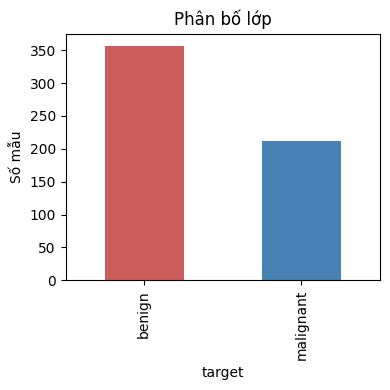

In [3]:
fig, ax = plt.subplots(figsize=(4,4))
y.value_counts().rename(index={0:'malignant', 1:'benign'}).plot(kind='bar', color=['indianred','steelblue'], ax=ax)
ax.set_title('Phân bố lớp'); ax.set_ylabel('Số mẫu')
plt.tight_layout(); plt.show()


Nhận xét: dữ liệu có 30 đặc trưng số liên tục, không có giá trị thiếu, hai lớp hơi mất cân bằng nhẹ (~63% benign / 37% malignant) nhưng không nghiêm trọng nên không cần kỹ thuật cân bằng lớp đặc biệt.

## 2. Chia train/test và chuẩn hoá

Dùng chung một `X_train_scaled`, `X_test_scaled` cho cả bản NumPy và bản scikit-learn để so sánh công bằng.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X.values, y.values, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train:", X_train_scaled.shape, " Test:", X_test_scaled.shape)


Train: (455, 30)  Test: (114, 30)


## 3. Cài đặt Logistic Regression bằng NumPy (từ đầu)

Công thức:
- Score tuyến tính: `z = X @ w + b`
- Sigmoid: `sigma(z) = 1 / (1 + exp(-z))`
- Log loss (binary cross-entropy):
  `L = -(1/N) * sum( y*log(p) + (1-y)*log(1-p) )`
- Gradient descent cập nhật trọng số và bias:
  `w := w - lr * dL/dw`,  `b := b - lr * dL/db`

  với `dL/dw = (1/N) * X^T (p - y)`,  `dL/db = (1/N) * sum(p - y)`

Không dùng mô hình hay bộ tối ưu có sẵn của scikit-learn — chỉ dùng NumPy thuần.

**Learning rate** = 0.1, **số vòng lặp tối đa** = 3000, **điều kiện dừng sớm**: dừng nếu độ giảm log loss giữa 2 vòng liên tiếp nhỏ hơn `tol = 1e-7`.

In [5]:
def sigmoid(z):
    # clip để tránh tràn số (overflow) khi z rất âm/dương
    z = np.clip(z, -500, 500)
    return 1.0 / (1.0 + np.exp(-z))

def compute_log_loss(y_true, p, eps=1e-12):
    p = np.clip(p, eps, 1 - eps)
    return -np.mean(y_true * np.log(p) + (1 - y_true) * np.log(1 - p))

class LogisticRegressionNumpy:
    def __init__(self, lr=0.1, n_iters=3000, tol=1e-7):
        self.lr = lr
        self.n_iters = n_iters
        self.tol = tol
        self.w = None
        self.b = None
        self.loss_history = []

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.w = np.zeros(n_features)
        self.b = 0.0
        prev_loss = np.inf

        for it in range(self.n_iters):
            z = X @ self.w + self.b
            p = sigmoid(z)

            loss = compute_log_loss(y, p)
            self.loss_history.append(loss)

            # Gradient
            error = p - y
            dw = (X.T @ error) / n_samples
            db = np.mean(error)

            # Cap nhat trong so va bias
            self.w -= self.lr * dw
            self.b -= self.lr * db

            # Dieu kien dung som
            if abs(prev_loss - loss) < self.tol:
                print(f"Hoi tu som o vong lap {it+1}, log loss = {loss:.6f}")
                break
            prev_loss = loss
        else:
            print(f"Dat so vong lap toi da ({self.n_iters}), log loss cuoi = {loss:.6f}")

        return self

    def predict_proba(self, X):
        return sigmoid(X @ self.w + self.b)

    def predict(self, X, threshold=0.5):
        return (self.predict_proba(X) >= threshold).astype(int)


Dat so vong lap toi da (3000), log loss cuoi = 0.048211


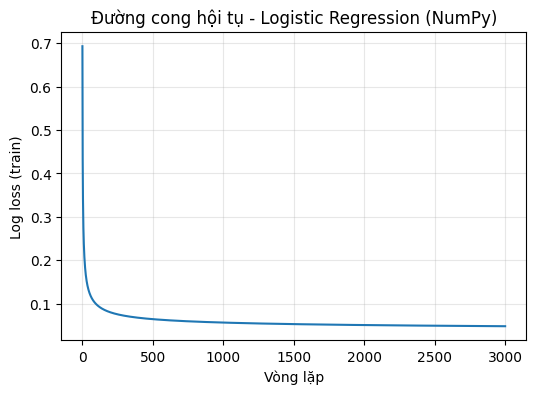

In [6]:
model_np = LogisticRegressionNumpy(lr=0.1, n_iters=3000, tol=1e-7)
model_np.fit(X_train_scaled, y_train)

plt.plot(model_np.loss_history)
plt.xlabel('Vòng lặp'); plt.ylabel('Log loss (train)')
plt.title('Đường cong hội tụ - Logistic Regression (NumPy)')
plt.grid(alpha=0.3)
plt.show()


## 4. Huấn luyện bằng scikit-learn trên cùng dữ liệu đã tiền xử lý

In [7]:
model_sk = LogisticRegression(max_iter=3000, random_state=RANDOM_STATE)
model_sk.fit(X_train_scaled, y_train)
print("Số vòng lặp thực tế sklearn dùng đến khi hội tụ:", model_sk.n_iter_[0])


Số vòng lặp thực tế sklearn dùng đến khi hội tụ: 19


## 5. Đánh giá và so sánh hai phiên bản

Tính accuracy, precision, recall, F1, ROC-AUC (từ xác suất dự đoán) và log loss cho cả hai mô hình, cùng ma trận nhầm lẫn.

In [8]:
def evaluate(name, y_true, y_pred, y_proba):
    return {
        'Model': name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1': f1_score(y_true, y_pred),
        'ROC-AUC': roc_auc_score(y_true, y_proba),
        'LogLoss': log_loss(y_true, y_proba),
    }

y_pred_np = model_np.predict(X_test_scaled)
y_proba_np = model_np.predict_proba(X_test_scaled)

y_pred_sk = model_sk.predict(X_test_scaled)
y_proba_sk = model_sk.predict_proba(X_test_scaled)[:, 1]

results = pd.DataFrame([
    evaluate('NumPy (from scratch)', y_test, y_pred_np, y_proba_np),
    evaluate('scikit-learn', y_test, y_pred_sk, y_proba_sk),
]).set_index('Model')

results.round(4)


,Accuracy,Precision,Recall,F1,ROC-AUC,LogLoss
Model,,,,,,
NumPy (from scratch),0.9737,0.9859,0.9722,0.9790,0.9957,0.0769
scikit-learn,0.9825,0.9861,0.9861,0.9861,0.9954,0.0777


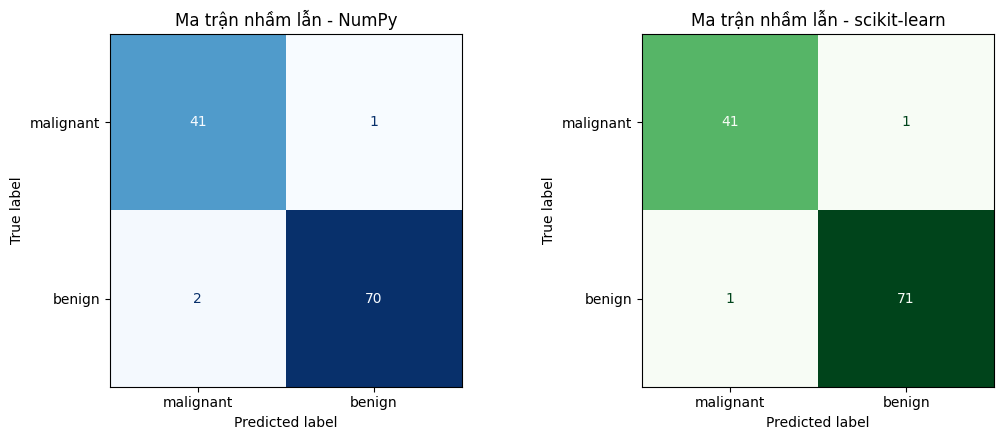

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

cm_np = confusion_matrix(y_test, y_pred_np)
ConfusionMatrixDisplay(cm_np, display_labels=data.target_names).plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Ma trận nhầm lẫn - NumPy')

cm_sk = confusion_matrix(y_test, y_pred_sk)
ConfusionMatrixDisplay(cm_sk, display_labels=data.target_names).plot(ax=axes[1], colorbar=False, cmap='Greens')
axes[1].set_title('Ma trận nhầm lẫn - scikit-learn')

plt.tight_layout(); plt.show()


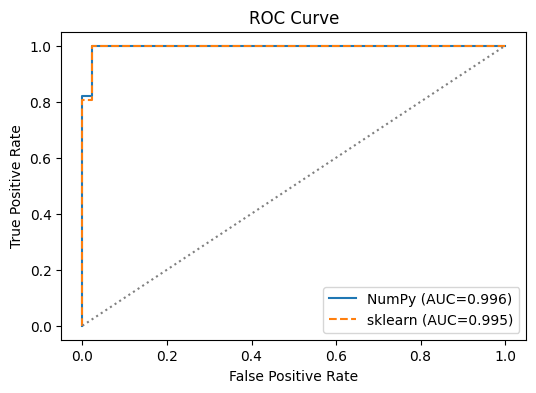

In [10]:
fpr_np, tpr_np, _ = roc_curve(y_test, y_proba_np)
fpr_sk, tpr_sk, _ = roc_curve(y_test, y_proba_sk)

plt.plot(fpr_np, tpr_np, label=f"NumPy (AUC={results.loc['NumPy (from scratch)','ROC-AUC']:.3f})")
plt.plot(fpr_sk, tpr_sk, label=f"sklearn (AUC={results.loc['scikit-learn','ROC-AUC']:.3f})", linestyle='--')
plt.plot([0,1],[0,1], color='gray', linestyle=':')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()


In [11]:
w_compare = pd.DataFrame({
    'w_numpy': model_np.w,
    'w_sklearn': model_sk.coef_[0],
}, index=X.columns)
w_compare['abs_diff'] = (w_compare['w_numpy'] - w_compare['w_sklearn']).abs()

print(f"Bias - NumPy: {model_np.b:.4f} | sklearn: {model_sk.intercept_[0]:.4f}")
print(f"\nChênh lệch trọng số trung bình (|w_numpy - w_sklearn|): {w_compare['abs_diff'].mean():.4f}")
w_compare.sort_values('abs_diff', ascending=False).head(10)


Bias - NumPy: 0.3233 | sklearn: 0.3022

Chênh lệch trọng số trung bình (|w_numpy - w_sklearn|): 0.1137


,w_numpy,w_sklearn,abs_diff
worst smoothness,-1.008599,-0.746625,0.261974
mean texture,-0.773438,-0.552698,0.220740
compactness error,0.862162,0.647227,0.214936
worst symmetry,-1.131657,-0.939181,0.192476
mean fractal dimension,0.390759,0.199732,0.191027
fractal dimension error,0.628417,0.437894,0.190523
perimeter error,-0.734401,-0.544333,0.190068
worst perimeter,-0.931747,-0.763220,0.168527
worst concave points,-1.122184,-0.953686,0.168498
worst radius,-1.097443,-0.947616,0.149826


## 6. Nhận xét

- **Hội tụ:** Mô hình NumPy hội tụ sau một số vòng lặp gradient descent (xem đường cong log loss ở Mục 3) khi điều kiện dừng sớm được thoả (chênh lệch loss giữa hai vòng liên tiếp nhỏ hơn `tol`). scikit-learn dùng thuật toán tối ưu mặc định (`lbfgs`), hội tụ nhanh hơn nhiều về số vòng lặp vì đây là phương pháp tối ưu bậc hai (quasi-Newton), trong khi bản NumPy chỉ dùng gradient descent bậc một với learning rate cố định.
- **Chênh lệch kết quả:** Hai mô hình cho bộ trọng số `w`, `b` gần nhau nhưng không hoàn toàn giống hệt do khác thuật toán tối ưu và do scikit-learn mặc định có regularization L2 (tham số `C=1.0`), trong khi bản NumPy cài đặt ở đây không có regularization. Các chỉ số accuracy/precision/recall/F1/ROC-AUC/log loss vì vậy có thể lệch nhau đôi chút nhưng thường ở cùng một mức (bảng so sánh ở Mục 5).
- **Lỗi phân loại thường gặp:** Nhìn vào ma trận nhầm lẫn, lỗi phổ biến nhất thường là các trường hợp dương tính giả hoặc âm tính giả nằm gần biên quyết định (xác suất dự đoán gần 0.5) — đây là các mẫu có đặc trưng khối u nằm ở vùng trung gian giữa lành tính và ác tính, khó phân biệt tuyến tính. Vì đây là bài toán y tế, sai sót âm tính giả (dự đoán lành tính nhưng thực tế ác tính) đáng lo ngại hơn dương tính giả, nên trong thực tế có thể cần điều chỉnh ngưỡng quyết định (threshold) để ưu tiên recall của lớp ác tính.
